# Analyzing P2Rank Output

This notebook shows how to load and explore the main output files produced by P2Rank:
- `*_predictions.csv` - predicted binding pockets with scores and residue assignments
- `*_residues.csv` - per-residue binding site predictions with scores and pocket assignments

In [1]:
%pip install pandas matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

output_dir = "p2rank_output/predict_1fbl"
protein = "1fbl.cif"

## Predicted Pockets

Each row is a predicted pocket. Key columns:
- **rank** - pocket rank (1 = most likely binding site)
- **score** - raw prediction score
- **probability** - estimated probability that the pocket is a true binding site
- **center_x/y/z** - pocket centroid coordinates
- **residue_ids** - residues forming the pocket (chain_residueNumber)

In [3]:
pockets = pd.read_csv(f"{output_dir}/{protein}_predictions.csv", skipinitialspace=True)
pockets

,name,rank,score,probability,sas_points,surf_atoms,center_x,center_y,center_z,residue_ids,surf_atom_ids
0,pocket1,1,9.77,0.525,70,40,70.5274,83.4375,-11.5099,A_103 A_180 A_181 A_182 A_183 A_184 A_186 A_21...,32 33 651 658 659 664 670 676 679 692 700 929 ...
1,pocket2,2,3.04,0.101,37,18,89.2267,98.6419,26.7534,A_337 A_339 A_341 A_348 A_357 A_360 A_362 A_36...,1890 1891 1909 1910 1926 1991 2064 2091 2092 2...
2,pocket3,3,2.94,0.095,34,15,61.1038,70.7493,-13.6472,A_119 A_156 A_160 A_162 A_164 A_168 A_191 A_19...,171 172 173 472 499 501 514 515 532 560 728 73...
3,pocket4,4,1.87,0.037,27,17,90.8572,95.9207,10.7905,A_290 A_291 A_293 A_304 A_320 A_321 A_340 A_35...,1488 1489 1490 1497 1499 1513 1619 1620 1756 1...


### Pocket residues

The `residue_ids` column contains space-separated residue identifiers. We can parse them to get a list.

In [4]:
# Residues of the top-ranked pocket
top_pocket = pockets.iloc[0]
residues_list = top_pocket["residue_ids"].split()
print(f"Pocket '{top_pocket['name']}' has {len(residues_list)} residues: {residues_list}")

Pocket 'pocket1' has 18 residues: ['A_103', 'A_180', 'A_181', 'A_182', 'A_183', 'A_184', 'A_186', 'A_214', 'A_215', 'A_218', 'A_219', 'A_222', 'A_226', 'A_227', 'A_228', 'A_238', 'A_239', 'A_240']


## Per-Residue Predictions

Each row is a protein residue. Key columns:
- **score** - raw ligandability score for the residue
- **probability** - estimated probability that the residue is part of a binding site
- **pocket** - assigned pocket number (0 = not part of any predicted pocket)

In [5]:
residues = pd.read_csv(f"{output_dir}/{protein}_residues.csv", skipinitialspace=True)
residues.head(10)

,chain,residue_label,residue_name,score,zscore,probability,pocket
0,A,100,PHE,0.5863,-0.0527,0.0491,0
1,A,101,VAL,0.1968,-0.2697,0.0067,0
2,A,102,LEU,0.0989,-0.3243,0.0023,0
3,A,103,THR,0.6058,-0.0418,0.0523,1
4,A,104,PRO,0.0206,-0.3680,0.0005,0
5,A,105,GLY,0.0092,-0.3743,0.0003,0
6,A,106,ASN,0.0249,-0.3656,0.0006,0
7,A,107,PRO,0.0174,-0.3698,0.0005,0
8,A,108,ARG,0.0233,-0.3664,0.0005,0
9,A,109,TRP,0.0864,-0.3313,0.0019,0


### Top scoring residues

In [6]:
residues.nlargest(10, "probability")[["chain", "residue_label", "residue_name", "probability", "pocket"]]

,chain,residue_label,residue_name,probability,pocket
128,A,228,HIS,0.7745,1
122,A,222,HIS,0.7509,1
119,A,219,GLU,0.7170,1
118,A,218,HIS,0.7135,1
83,A,183,HIS,0.6815,1
82,A,182,ALA,0.6739,1
84,A,184,ALA,0.5529,1
138,A,238,PRO,0.5377,1
80,A,180,ASN,0.3284,1
363,A,463,TRP,0.2855,0


### Residues by pocket

In [7]:
# Filter residues assigned to predicted pockets (pocket > 0)
pocket_residues = residues[residues["pocket"] > 0]
pocket_residues.groupby("pocket").agg(
    n_residues=("residue_label", "count"),
    avg_probability=("probability", "mean"),
    residue_names=("residue_name", lambda x: " ".join(x))
)

,n_residues,avg_probability,residue_names
pocket,,,
1,18,0.372128,THR ASN LEU ALA HIS ALA GLN ARG VAL HIS GLU HI...
2,12,0.059325,ARG GLU ARG TYR LEU TYR LYS ARG SER PHE TYR GLU
3,9,0.092122,GLU GLN MET SER VAL HIS ILE ASP HIS
4,9,0.029778,LEU ARG GLU ARG PHE TRP VAL GLY GLN


### Score distribution

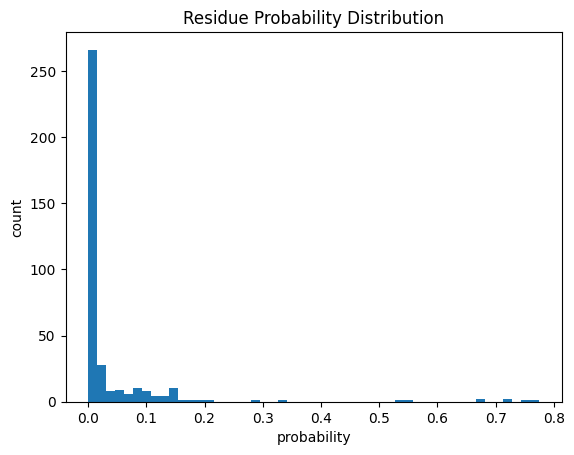

In [8]:
residues["probability"].plot.hist(bins=50, title="Residue Probability Distribution", xlabel="probability", ylabel="count")
plt.show()